# Linear Models - FX Pairs

**Docker image**: `ml4t`

Shared base and quote currencies make the 20-pair cross-section highly dependent.
The 61 financial and model-based features span momentum, volatility, carry proxies,
and ranked signals. This notebook tests whether regularized linear combinations of
those individually weak features improve one-day cross-sectional forecasts.

**Learning Objectives**:
- Compare OLS, Ridge, Lasso, and ElasticNet across eight purged walk-forward folds
- Examine how L1 sparsity and L2 shrinkage affect one-day validation IC
- Register or reload fold-complete validation predictions for downstream analysis

**Book Reference**: Chapter 11, Section 11.2 (Regularized Linear Models)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_model_based_features`](04_model_based_features.ipynb), and
[`02_labels`](02_labels.ipynb)

In [1]:
"""Linear Models - walk-forward cross-validation."""

import json
import time
from datetime import UTC, datetime

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.diagnostic.metrics import cross_sectional_ic
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, LogisticRegression, Ridge

from case_studies.utils.registry import (
    build_training_spec,
    get_training_dir,
    load_prediction_sets,
    read_predictions,
    register_prediction_set,
    register_training_run,
    training_hash_from_spec,
    training_run_status,
)
from utils.cv_splits import generate_cv_splits
from utils.modeling import (
    ConfigError,
    load_configs,
    load_modeling_dataset,
    prepare_cv_folds,
    resolve_linear_params,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS

In [2]:
CASE_STUDY_ID = "fx_pairs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows per fold (val is never sampled). Use for memory-constrained runs on large datasets.
MAX_FOLDS = 0

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

## 1. Load Data and Model Configs

Model configurations are defined in `config/training/{label}.yaml`. Each entry
references a preset in `config/` - a complete specification of
the sklearn class and its constructor parameters. To modify the grid,
edit the label config file: comment out presets or add new ones. A complete
registry match reloads its frozen validation metrics; `FORCE_RETRAIN=True`
recomputes the grid from the current upstream feature artifacts.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else None

# Fold-aware temporal features are fitted against the primary-label boundaries
# materialized by notebook 02 and consumed by notebook 04. Rebuilding folds from
# setup.yaml produces different boundaries and silently drops or crosses temporal
# state. Variant labels need their own embargo-specific temporal artifacts.
if setup["labels"]["primary"] != PRIMARY_LABEL:
    raise ConfigError(
        f"{PRIMARY_LABEL!r} has no matching fold-aware temporal artifact. "
        f"Run this notebook with the primary label {setup['labels']['primary']!r}."
    )
cv_config = json.loads((CASE_DIR / "config" / "cv_config.json").read_text())
splits = generate_cv_splits(
    dataset,
    cv_config=cv_config,
    label_buffer=mds.label_buffer,
    date_col=date_col,
)
splits = [
    {
        **split,
        **{
            key: pd.Timestamp(split[key])
            for key in ("train_start", "train_end", "val_start", "val_end")
        },
    }
    for split in splits[: MAX_FOLDS or None]
]

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")

Dataset: 77,440 rows × 61 features
Label: fwd_ret_1d | Task: regression | Folds: 8


In [5]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="linear")

print(f"\n{len(configs)} configs × {len(splits)} folds = {len(configs) * len(splits)} fits\n")
for cfg in configs:
    params_str = (
        ", ".join(f"{k}={v}" for k, v in cfg["params"].items()) if cfg["params"] else "defaults"
    )
    print(f"  {cfg['config_name']:25s}  {cfg['model_class']}({params_str})")


28 configs × 8 folds = 224 fits

  ols                        LinearRegression(defaults)
  ridge_a0.001               Ridge(alpha=0.001)
  ridge_a0.01                Ridge(alpha=0.01)
  ridge_a0.1                 Ridge(alpha=0.1)
  ridge_a1.0                 Ridge(alpha=1.0)
  ridge_a10.0                Ridge(alpha=10.0)
  ridge_a100.0               Ridge(alpha=100.0)
  ridge_a1000.0              Ridge(alpha=1000.0)
  ridge_a10000.0             Ridge(alpha=10000.0)
  ridge_a100000.0            Ridge(alpha=100000.0)
  ridge_a1000000.0           Ridge(alpha=1000000.0)
  ridge_a10000000.0          Ridge(alpha=10000000.0)
  lasso_f0.5                 Lasso(alpha_frac=0.5, max_iter=5000)
  lasso_f0.2                 Lasso(alpha_frac=0.2, max_iter=5000)
  lasso_f0.08                Lasso(alpha_frac=0.08, max_iter=5000)
  lasso_f0.03                Lasso(alpha_frac=0.03, max_iter=5000)
  lasso_f0.015               Lasso(alpha_frac=0.015, max_iter=5000)
  lasso_f0.35                Lasso(alph

## 2. Prepare CV Folds

Each fold uses the boundaries materialized in `config/cv_config.json`, so its ID
selects the matching model-based artifact from notebook 04. Median imputation
and standard scaling fit on training rows and then transform validation rows.

In [6]:
dataset_pd = dataset.to_pandas()
folds = prepare_cv_folds(
    dataset_pd,
    splits,
    feature_names,
    label_col,
    date_col,
    entity_col,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    train_sample_frac=TRAIN_SAMPLE_FRAC,
)

for f in folds:
    if f["X_train"].shape[1] != len(feature_names) or f["X_val"].shape[1] != len(feature_names):
        raise ConfigError(
            f"Fold {f['fold']} retained {f['X_train'].shape[1]}/{len(feature_names)} features; "
            "check model-based fold alignment before training."
        )
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

  Fold 0: train=24,840  val=5,420
  Fold 1: train=25,940  val=5,300
  Fold 2: train=26,560  val=5,340
  Fold 3: train=26,920  val=4,600
  Fold 4: train=26,120  val=5,420
  Fold 5: train=26,160  val=5,400
  Fold 6: train=26,140  val=5,320
  Fold 7: train=26,160  val=5,360


## 3. Walk-Forward Cross-Validation

For each configuration, fit the model on each training fold and predict
the validation fold. Cross-sectional IC (Spearman rank correlation per
date, averaged) measures predictive quality.

In [7]:
# sklearn class lookup - maps model_class strings from presets to classes
MODEL_CLASSES = {
    "LinearRegression": LinearRegression,
    "Ridge": Ridge,
    "Lasso": Lasso,
    "ElasticNet": ElasticNet,
    "LogisticRegression": LogisticRegression,
}

IC_STD_DDOF = 0

Fold-level IC aggregation uses population dispersion (`ddof=0`) on cached and fresh paths.

In [8]:
def _aggregate_fold_ics(fold_ics):
    """Return one consistent mean and dispersion definition for fold ICs."""
    values = np.asarray(fold_ics, dtype=float)
    return float(np.nanmean(values)), float(np.nanstd(values, ddof=IC_STD_DDOF))

Cached summaries are rebuilt from frozen prediction rows so legacy registry
metrics cannot change the meaning of the displayed dispersion.

In [9]:
def _load_cached_ic_summary(prediction_hash):
    """Recompute cached fold metrics from their frozen prediction rows."""
    predictions = read_predictions(CASE_STUDY_ID, prediction_hash)
    fold_summaries = []
    for fold_id in sorted(predictions["fold_id"].unique().drop_nulls().to_list()):
        fold_predictions = predictions.filter(pl.col("fold_id") == fold_id)
        fold_summaries.append(
            cross_sectional_ic(
                fold_predictions,
                fold_predictions,
                pred_col="y_score",
                ret_col="y_true",
                date_col="timestamp",
                entity_col="symbol",
                min_obs=5,
            )
        )
    fold_ics = [summary["ic_mean"] for summary in fold_summaries]
    ic_mean, ic_std = _aggregate_fold_ics(fold_ics)
    return ic_mean, ic_std, float(sum(summary["n_periods"] for summary in fold_summaries)), fold_ics

A complete registry entry avoids unnecessary fitting while still returning the
metrics needed by the summary and figures. Incomplete entries fall through to
the same fold-fitting path a fresh checkout uses.

In [10]:
def _load_cached_result(cfg):
    """Return a cached result and registry status, or None when retraining is required."""
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(folds),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    status = training_run_status(CASE_STUDY_ID, spec)
    prediction_sets = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=training_hash_from_spec(spec),
        split=PREDICTION_SPLIT,
    )
    if FORCE_RETRAIN or not status.complete or prediction_sets.is_empty():
        return None, status

    prediction_hash = prediction_sets["prediction_hash"][0]
    ic_mean, ic_std, ic_n_days, fold_ics = _load_cached_ic_summary(prediction_hash)
    result = {
        "config": cfg,
        "predictions": pd.DataFrame(),
        "ic_mean": ic_mean,
        "ic_std": ic_std,
        "ic_n_days": ic_n_days,
        "fold_ics": fold_ics,
        "degenerate": False,
        "cached": True,
        "started_at": None,
        "elapsed_s": 0.0,
    }
    return result, status

Model construction resolves data-dependent L1 penalties inside each training
fold. Invalid preset parameters fail with the configuration name attached.

In [11]:
def _make_model(cfg, fold):
    """Instantiate one fold-specific sklearn model."""
    cls = MODEL_CLASSES.get(cfg["model_class"])
    if cls is None:
        raise ConfigError(
            f"Unknown model_class '{cfg['model_class']}' in preset '{cfg['config_name']}'.\n"
            f"Available: {list(MODEL_CLASSES.keys())}"
        )
    try:
        return cls(**resolve_linear_params(cfg, fold["X_train"], fold["y_train"]))
    except TypeError as exc:
        raise ConfigError(
            f"Cannot create {cfg['model_class']} from preset '{cfg['config_name']}'.\n"
            f"Check preset params for {cfg['config_name']}: {exc}"
        ) from exc

Coefficients are retained per fold for later model inspection. The intercept is
stored beside the feature weights under a reserved name.

In [12]:
def _coefficient_rows(model, cfg, fold_id):
    """Return registry-ready coefficient rows for one fitted model."""
    if not hasattr(model, "coef_"):
        return []
    coefficients = model.coef_.ravel() if model.coef_.ndim > 1 else model.coef_
    intercept = model.intercept_ if np.isscalar(model.intercept_) else model.intercept_[0]
    rows = [
        {
            "config_name": cfg["config_name"],
            "fold": fold_id,
            "feature": feature,
            "coefficient": float(coefficient),
        }
        for feature, coefficient in zip(feature_names, coefficients, strict=False)
    ]
    rows.append(
        {
            "config_name": cfg["config_name"],
            "fold": fold_id,
            "feature": "_intercept_",
            "coefficient": float(intercept),
        }
    )
    return rows

A fold fit produces predictions, daily cross-sectional IC coverage, and the
coefficient rows. An all-zero coefficient vector marks an unusable configuration.

In [13]:
def _fit_one_fold(cfg, fold):
    """Fit and evaluate one configuration on one walk-forward fold."""
    model = _make_model(cfg, fold)
    model.fit(fold["X_train"], fold["y_train"])
    if hasattr(model, "coef_") and np.all(model.coef_ == 0):
        return None

    if mds.task_type == "classification" and hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(fold["X_val"])
        predictions = probabilities @ np.array(sorted(mds.class_values), dtype=np.float64)
    else:
        predictions = model.predict(fold["X_val"])

    ic_frame = pl.DataFrame(
        {
            "date": fold["dates"],
            "symbol": fold["entities"],
            "y_true": fold["y_val"],
            "y_pred": predictions,
        }
    )
    ic_summary = cross_sectional_ic(
        ic_frame,
        ic_frame,
        pred_col="y_pred",
        ret_col="y_true",
        date_col="date",
        entity_col="symbol",
        min_obs=5,
    )
    prediction_frame = fold["meta"][mds.join_cols].copy()
    prediction_frame["fold"] = fold["fold"]
    prediction_frame["prediction"] = predictions
    prediction_frame["actual"] = fold["y_val"]
    return prediction_frame, ic_summary, _coefficient_rows(model, cfg, fold["fold"])

Configuration-level aggregation keeps fold metrics separate until all eight
fits complete, then records their mean, dispersion, and total valid-day coverage.

In [14]:
def _fit_config(cfg):
    """Fit one configuration across all folds and return its aggregate result."""
    started_at = datetime.now(UTC).isoformat()
    start = time.perf_counter()
    fold_results = [_fit_one_fold(cfg, fold) for fold in folds]
    elapsed_s = time.perf_counter() - start
    if any(result is None for result in fold_results):
        return {
            "config": cfg,
            "predictions": pd.DataFrame(),
            "ic_mean": np.nan,
            "ic_std": np.nan,
            "ic_n_days": np.nan,
            "fold_ics": [],
            "degenerate": True,
            "started_at": started_at,
            "elapsed_s": elapsed_s,
        }

    prediction_frames, ic_summaries, coefficient_groups = zip(*fold_results, strict=True)
    fold_ics = [summary["ic_mean"] for summary in ic_summaries]
    ic_mean, ic_std = _aggregate_fold_ics(fold_ics)
    return {
        "config": cfg,
        "predictions": pd.concat(prediction_frames, ignore_index=True),
        "ic_mean": ic_mean,
        "ic_std": ic_std,
        "ic_n_days": float(sum(summary["n_periods"] for summary in ic_summaries)),
        "fold_ics": fold_ics,
        "coefficients": [row for group in coefficient_groups for row in group],
        "degenerate": False,
        "started_at": started_at,
        "elapsed_s": elapsed_s,
    }

In [15]:
results = []
for cfg in configs:
    result, status = _load_cached_result(cfg)
    if result is not None:
        print(
            f"  {cfg['config_name']:25s}  IC={result['ic_mean']:+.4f} ± "
            f"{result['ic_std']:.4f}  (cached, {status.summary()})"
        )
    elif status.complete:
        print(f"  {cfg['config_name']:25s}  RETRAIN - missing {PREDICTION_SPLIT} predictions")
    else:
        if status.partial:
            print(f"  {cfg['config_name']:25s}  RETRAIN - partial state: {status.summary()}")
        result = _fit_config(cfg)
        suffix = "SKIP - all coefficients zero" if result["degenerate"] else "trained"
        print(f"  {cfg['config_name']:25s}  {suffix} ({result['elapsed_s']:.1f}s)")
    results.append(result)

  ols                        IC=-0.0045 ± 0.0275  (cached, complete (hash=12e545fc9e16))
  ridge_a0.001               IC=-0.0045 ± 0.0275  (cached, complete (hash=df0d3652dcb6))


  ridge_a0.01                IC=-0.0045 ± 0.0275  (cached, complete (hash=50314a906f23))


  ridge_a0.1                 IC=-0.0044 ± 0.0275  (cached, complete (hash=040dd2167fff))
  ridge_a1.0                 IC=-0.0045 ± 0.0275  (cached, complete (hash=9736a10108a0))


  ridge_a10.0                IC=-0.0043 ± 0.0277  (cached, complete (hash=533092b66783))


  ridge_a100.0               IC=-0.0042 ± 0.0272  (cached, complete (hash=011ccd41c932))
  ridge_a1000.0              IC=-0.0007 ± 0.0280  (cached, complete (hash=6c9594dc1541))


...

  lasso_f0.5                 IC=-0.0006 ± 0.0340  (cached, complete (hash=d25e2b8d079e))
  lasso_f0.2                 IC=+0.0021 ± 0.0390  (cached, complete (hash=a3e041094908))
  lasso_f0.08                IC=-0.0005 ± 0.0328  (cached, complete (hash=162d48fb94fc))


  lasso_f0.03                IC=-0.0028 ± 0.0291  (cached, complete (hash=3f61b7c3cce6))
  lasso_f0.015               IC=-0.0047 ± 0.0287  (cached, complete (hash=6e50a6b95026))
  lasso_f0.35                IC=+0.0010 ± 0.0346  (cached, complete (hash=7a41ca3abdd9))


  lasso_f0.7                 IC=-0.0027 ± 0.0337  (cached, complete (hash=21fbd092f73f))
  lasso_f0.85                IC=-0.0059 ± 0.0336  (cached, complete (hash=3372c88682cb))
  enet_f0.5                  IC=-0.0006 ± 0.0340  (cached, complete (hash=15606f9c72e3))


  enet_f0.2                  IC=+0.0021 ± 0.0390  (cached, complete (hash=416926d8f57f))
  enet_f0.08                 IC=-0.0005 ± 0.0328  (cached, complete (hash=89a9996d7af6))
  enet_f0.03                 IC=-0.0028 ± 0.0291  (cached, complete (hash=3644ffe79370))
  enet_f0.015                IC=-0.0047 ± 0.0287  (cached, complete (hash=265698f2d20a))


  enet_f0.35                 IC=+0.0010 ± 0.0346  (cached, complete (hash=ac0e2555fc27))
  enet_f0.7                  IC=-0.0027 ± 0.0337  (cached, complete (hash=eb61ae4a32cb))
  enet_f0.85                 IC=-0.0059 ± 0.0336  (cached, complete (hash=7d5f93efb27f))


## 4. Results Summary

On a complete checkout, these are the frozen-registry validation metrics rather
than a retrain on the corrected upstream artifact vintage. Rank configurations
by mean IC, require equal coverage, and compare the strongest setting per family.

In [16]:
# Sort by IC descending
results.sort(key=lambda r: r["ic_mean"] if np.isfinite(r["ic_mean"]) else -np.inf, reverse=True)

active = [r for r in results if not r.get("degenerate")]
degenerate = [r for r in results if r.get("degenerate")]

# A configuration whose predictions are constant on some validation dates has
# fewer defined daily IC observations. Rank only configurations with the maximum
# observed coverage so unlike samples cannot determine the reported winner.
finite_cov = [r for r in active if np.isfinite(r.get("ic_n_days", np.nan))]
if finite_cov:
    _full_days = max(r["ic_n_days"] for r in finite_cov)
    full_cov = [r for r in finite_cov if r["ic_n_days"] == _full_days]
    partial_cov = [r for r in finite_cov if r["ic_n_days"] < _full_days]
    missing_cov = [r for r in active if not np.isfinite(r.get("ic_n_days", np.nan))]
else:
    # Legacy registries may not carry coverage; retain the active-set fallback.
    _full_days = None
    full_cov = active
    partial_cov = []
    missing_cov = []

In [17]:
if _full_days is not None:
    print(
        f"Full validation coverage: {len(full_cov)}/{len(active)} configs x {int(_full_days):,} days"
    )
if partial_cov:
    print("Partial coverage (excluded from ranking):")
    for r in partial_cov:
        print(
            f"  {r['config']['config_name']:25s}  IC={r['ic_mean']:+.4f}  "
            f"days={int(r['ic_n_days']):,}/{int(_full_days):,}"
        )
if missing_cov:
    print("Missing coverage (excluded from ranking):")
    for r in missing_cov:
        print(f"  {r['config']['config_name']:25s}  IC={r['ic_mean']:+.4f}  days=unavailable")
if degenerate:
    print(f"\nSkipped ({len(degenerate)} degenerate - all coefficients zero):")
    for r in degenerate:
        print(f"  {r['config']['config_name']}")

best = full_cov[0] if full_cov else None
if best:
    print(f"Best full-coverage config: {best['config']['config_name']} (IC={best['ic_mean']:+.4f})")

Full validation coverage: 28/28 configs x 2,064 days
Best full-coverage config: ridge_a10000.0 (IC=+0.0052)


### Strong Ridge shrinkage leads, but one-day IC remains small

Comparing the strongest full-coverage configuration from each estimator family
separates the effect of regularization from grid density. The zero reference is
economically important: the ranking leader is positive, but its mean IC is only
about half a percent.

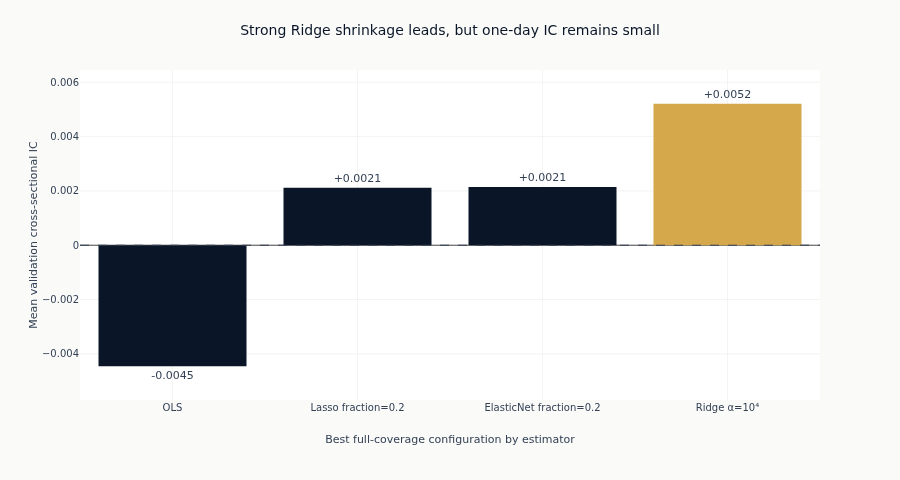

In [18]:
_SUPERSCRIPT = str.maketrans("0123456789-", "⁰¹²³⁴⁵⁶⁷⁸⁹⁻")


def _pretty_config(name):
    """Return a compact display label for a linear-model configuration."""
    if name.startswith("ridge_a"):
        exponent = int(round(np.log10(float(name.split("_a")[1]))))
        return f"Ridge α=10{str(exponent).translate(_SUPERSCRIPT)}"
    if name.startswith("lasso_f"):
        return f"Lasso fraction={name.split('_f')[1]}"
    if name.startswith("enet_f"):
        return f"ElasticNet fraction={name.split('_f')[1]}"
    return "OLS" if name == "ols" else name


_family_best = {}
for _result in full_cov:
    _family_best.setdefault(_result["config"]["model_class"], _result)
_family_order = ["LinearRegression", "Lasso", "ElasticNet", "Ridge"]
_family_results = [_family_best[name] for name in _family_order if name in _family_best]
_family_labels = [_pretty_config(r["config"]["config_name"]) for r in _family_results]
_family_ics = [r["ic_mean"] for r in _family_results]
_family_colors = [COLORS["amber"] if r is best else COLORS["blue"] for r in _family_results]

fig_family = go.Figure(
    go.Bar(
        x=_family_labels,
        y=_family_ics,
        marker_color=_family_colors,
        text=[f"{value:+.4f}" for value in _family_ics],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_family.add_hline(y=0, line_color=COLORS["neutral"], line_dash="dash", line_width=1)
fig_family.update_layout(
    title="Strong Ridge shrinkage leads, but one-day IC remains small",
    height=480,
    width=900,
    showlegend=False,
    margin=dict(t=70),
)
fig_family.update_xaxes(title_text="Best full-coverage configuration by estimator")
fig_family.update_yaxes(title_text="Mean validation cross-sectional IC")
fig_family.show()

### Ridge improves only after substantial shrinkage

The Ridge path is flat near the OLS result at weak penalties. IC crosses zero
only after substantial shrinkage, peaks at $\alpha=10^4$, and then declines.
This shape is consistent with many correlated predictors carrying weak, diffuse
information rather than a small set of dominant coefficients.

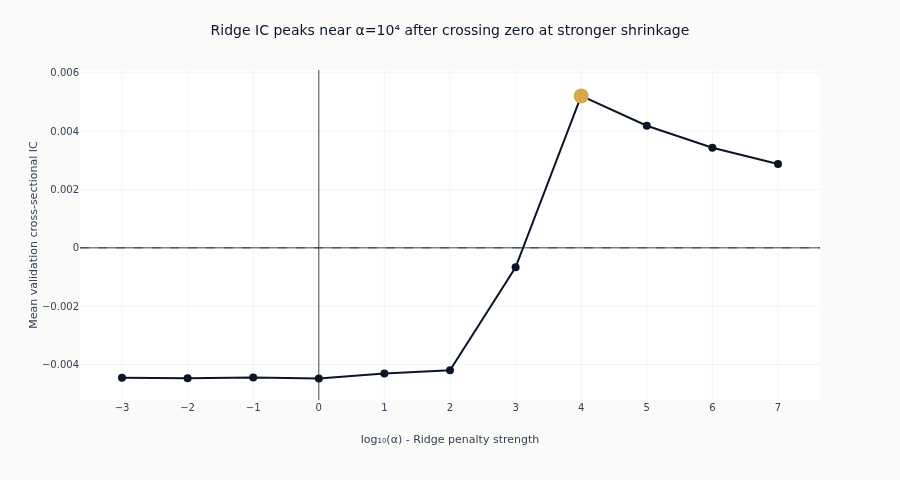

In [19]:
_ridge_results = sorted(
    (
        float(r["config"]["config_name"].split("_a")[1]),
        r["ic_mean"],
    )
    for r in full_cov
    if r["config"]["config_name"].startswith("ridge_a")
)
_ridge_log_alpha = [np.log10(alpha) for alpha, _ in _ridge_results]
_ridge_ic = [ic for _, ic in _ridge_results]
_ridge_peak = int(np.argmax(_ridge_ic))

fig_ridge = go.Figure(
    go.Scatter(
        x=_ridge_log_alpha,
        y=_ridge_ic,
        mode="lines+markers",
        line=dict(color=COLORS["blue"], width=2),
        marker=dict(color=COLORS["blue"], size=8),
    )
)
fig_ridge.add_trace(
    go.Scatter(
        x=[_ridge_log_alpha[_ridge_peak]],
        y=[_ridge_ic[_ridge_peak]],
        mode="markers",
        marker=dict(color=COLORS["amber"], size=15),
        showlegend=False,
    )
)
fig_ridge.add_hline(y=0, line_color=COLORS["neutral"], line_dash="dash", line_width=1)
fig_ridge.update_layout(
    title="Ridge IC peaks near α=10⁴ after crossing zero at stronger shrinkage",
    height=480,
    width=900,
    showlegend=False,
    margin=dict(t=70),
)
fig_ridge.update_xaxes(title_text="log₁₀(α) - Ridge penalty strength", dtick=1)
fig_ridge.update_yaxes(title_text="Mean validation cross-sectional IC")
fig_ridge.show()

**Interpretation**: all 28 frozen-registry configurations cover the same 2,064
validation dates.
Ridge at $\alpha=10^4$ leads with IC $+0.0052$, versus $-0.0045$ for OLS and
about $+0.0021$ for the best Lasso and ElasticNet settings. This is a validation
ranking, not evidence that the small edge is statistically reliable.

## 5. Register Results

Each config is registered in the unified registry with its predictions,
IC metrics, and full provenance (training hash = SHA256 of config + label
+ named feature sets + fold count). Identical specs produce the same hash; re-running
updates rather than duplicates.

In [20]:
for r in active:
    if r.get("cached"):
        continue  # already registered on a prior run; predictions not reloaded
    cfg = r["config"]
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(folds),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    t_hash = register_training_run(
        CASE_STUDY_ID,
        spec=spec,
        entry_point="06_linear",
        started_at=r.get("started_at"),
        elapsed_s=r.get("elapsed_s"),
    )

    # Save coefficients to registry training dir
    train_dir = get_training_dir(CASE_STUDY_ID, spec)
    coefs = r.get("coefficients", [])
    if coefs:
        pd.DataFrame(coefs).to_parquet(train_dir / "coefficients.parquet", index=False)

    metrics = {"ic_mean": r["ic_mean"], "ic_std": r["ic_std"]}
    register_prediction_set(
        CASE_STUDY_ID,
        t_hash,
        split=PREDICTION_SPLIT,
        predictions=r["predictions"],
        task_type=mds.task_type,
        class_values=mds.class_values or None,
        metrics=metrics,
    )
    print(f"  registered {cfg['config_name']:25s}  IC={r['ic_mean']:+.4f}")

## 6. Key Takeaways

Strong L2 shrinkage improves the one-day linear ranking relative to OLS and the
sparse L1 alternatives, but the best mean validation IC is still only $+0.0052$.
The result sets a deliberately low linear benchmark: the next notebook tests
whether non-linear interactions add economically meaningful rank information.

**Next**: [`07_gbm`](07_gbm.ipynb) tests gradient boosting with 15 tree-depth x loss
configurations to evaluate non-linear feature interactions.